# Projet Text Mining — Feature Selection sur LSTM
## Comparaison de 3 méthodes de Feature Selection
### ENSAM Casablanca — 2025/2026
---

# Sprint 1 — Analyse Exploratoire des Données (EDA)
---

## 0. Imports & Configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import os
import warnings
import arabic_reshaper
from bidi.algorithm import get_display

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

DATA_PATH    = '../data/raw/'
FIGURES_PATH = '../results/figures/'
os.makedirs(FIGURES_PATH, exist_ok=True)

LABEL_NAMES = {1: 'Positif', 0: 'Négatif'}

print('Imports OK')

Imports OK


## 1. Chargement & Fusion

In [ ]:
df_pos = pd.read_csv(DATA_PATH + 'train_pos.tsv', sep='\t', header=None)
df_neg = pd.read_csv(DATA_PATH + 'train_neg.tsv', sep='\t', header=None)
df_pos.columns = ['label_raw', 'text']
df_neg.columns = ['label_raw', 'text']

df_pos['label'] = 1
df_neg['label'] = 0

df = pd.concat([df_pos, df_neg], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df['label_name'] = df['label'].map(LABEL_NAMES)

print(f'Total : {len(df):,} tweets')
print(f'Colonnes : {list(df.columns)}')

df.head(10)

Total : 11,520 tweets
Colonnes : ['label_raw', 'text', 'label', 'label_name']


,label_raw,text,label,label_name
0,pos,#مسابقة والجائزة 💰 / من أول من فتق لسانه بالعر...,1,Positif
1,neg,❥↓🌿🍥 ما لأبن أدم والفخر اوله نطفه وأخره جيفه و...,0,Négatif
2,pos,"✨ لاتحزن ودع القلق,يستجيب لك الكريم هو يأخرها ...",1,Positif
3,neg,بيي الله يستر طلعتي من الدوام سيارتي وايد نازل...,0,Négatif
4,neg,تلاتين سنة بترقص .. الليلة رقصتنا أنا ببكي 😭 د...,0,Négatif
5,pos,لا فض فوك بو أحمد، وصبحك الله بالخير 💐,1,Positif
6,pos,بمناسبة فوز الهلال .. 💙 سحب على آيفون XR📱 رتوي...,1,Positif
7,pos,ربي أجرني..قد أتيتك مذنبا أنت الكريم ومن تجير ...,1,Positif
8,neg,والله الثلاثة اتفه من بعض العروس كريهة شو يعني...,0,Négatif
9,pos,في كل شخص منا شيئا عظيما أوجده الله فيه ، ووضع...,1,Positif


## 2. Vue Générale

In [ ]:
print(df.shape)       
print(df.info())      
df.describe(include='all')  

(11520, 4)
<class 'pandas.DataFrame'>
RangeIndex: 11520 entries, 0 to 11519
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   label_raw   11520 non-null  str  
 1   text        11520 non-null  str  
 2   label       11520 non-null  int64
 3   label_name  11520 non-null  str  
dtypes: int64(1), str(3)
memory usage: 360.1 KB
None


,label_raw,text,label,label_name
count,11520,11520,11520.000000,11520
unique,2,8817,NaN,2
top,neg,بمناسبة فوز الهلال .. 💙 سحب على آيفون XR📱 رتوي...,NaN,Négatif
freq,5768,108,NaN,5768
mean,NaN,NaN,0.499306,NaN
std,NaN,NaN,0.500021,NaN
min,NaN,NaN,0.000000,NaN
25%,NaN,NaN,0.000000,NaN
50%,NaN,NaN,0.000000,NaN
75%,NaN,NaN,1.000000,NaN


## 3. Distribution des Classes

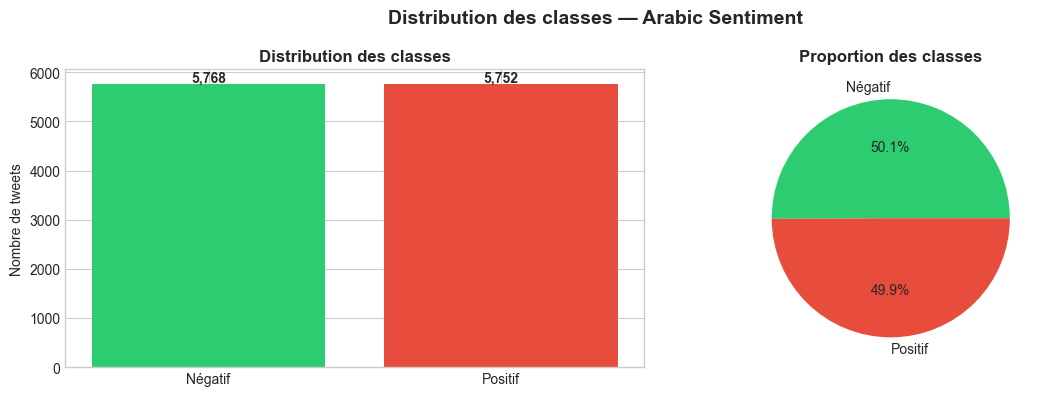

Ratio déséquilibre : 1.00x


In [ ]:
label_counts = df['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(
    [LABEL_NAMES[k] for k in label_counts.index],
    label_counts.values,
    color=['#2ecc71', '#e74c3c']
)
axes[0].set_title('Distribution des classes', fontweight='bold')
axes[0].set_ylabel('Nombre de tweets')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(
    label_counts.values,
    labels=[LABEL_NAMES[k] for k in label_counts.index],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c']
)
axes[1].set_title('Proportion des classes', fontweight='bold')

plt.suptitle('Distribution des classes — Arabic Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}ds2_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = label_counts.max() / label_counts.min()
print(f'Ratio déséquilibre : {ratio:.2f}x')

## 4. Analyse de la Longueur des Tweets

=== Statistiques longueur (mots) ===
count    11520.0
mean        13.2
std         14.0
min          3.0
25%          6.0
50%         13.0
75%         19.0
max        813.0
Name: word_count, dtype: float64


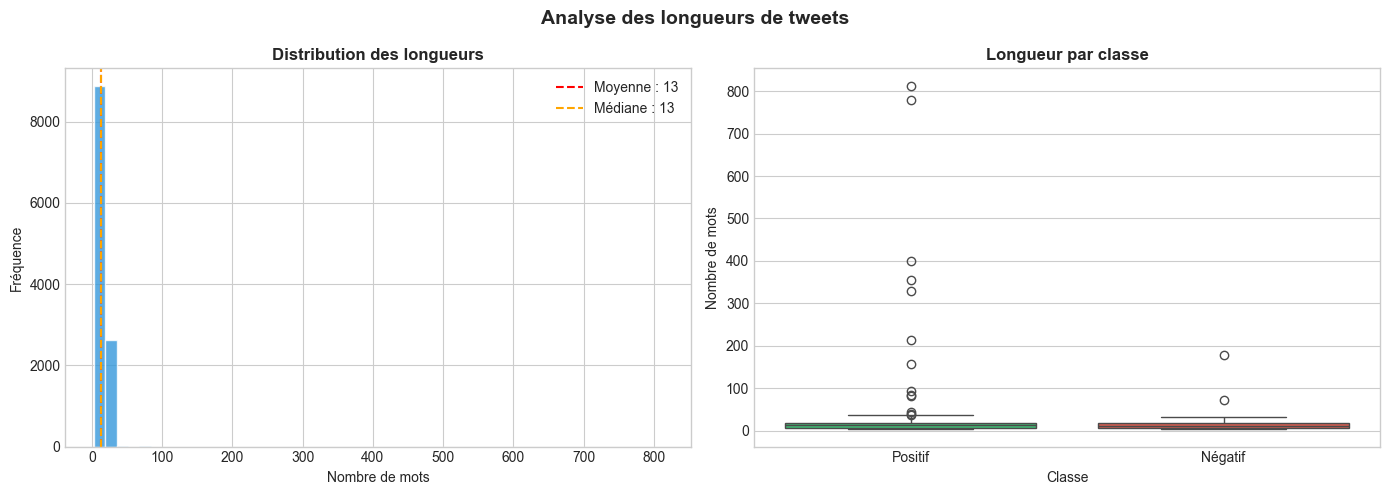

In [ ]:
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split())).astype(int)
df['char_count'] = df['text'].astype(str).apply(len)

print('=== Statistiques longueur (mots) ===')
print(df['word_count'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme global
axes[0].hist(df['word_count'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f"Moyenne : {df['word_count'].mean():.0f}")
axes[0].axvline(df['word_count'].median(), color='orange', linestyle='--', label=f"Médiane : {df['word_count'].median():.0f}")
axes[0].set_title('Distribution des longueurs', fontweight='bold')
axes[0].set_xlabel('Nombre de mots')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

# Boxplot par classe
sns.boxplot(data=df, x='label_name', y='word_count', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Longueur par classe', fontweight='bold')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Nombre de mots')

plt.suptitle('Analyse des longueurs de tweets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}ds2_text_length.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
df.loc[df['word_count'].idxmax()]

label_raw                                                   pos
text           ﴿وجزاهم بما صبروا جنة وحريرا ﴾ على سبيل الراح...
label                                                         1
label_name                                              Positif
word_count                                                  813
char_count                                                 4049
Name: 8604, dtype: object

## 5. Qualité des Données

In [ ]:
print('=== Valeurs nulles ===')
print(df.isnull().sum())

print('\n=== Tweets vides ===')
empty = df['text'].astype(str).str.strip().eq('').sum()
print(f'{empty} tweets vides')

print('\n=== Tweets dupliqués ===')
dupes = df.duplicated(subset='text').sum()
print(f'{dupes} tweets dupliqués ({dupes/len(df)*100:.1f}%)')


print(f'Tweets avec +50 mots : {(df["word_count"] > 50).sum()}')

=== Valeurs nulles ===
label_raw     0
text          0
label         0
label_name    0
word_count    0
char_count    0
dtype: int64

=== Tweets vides ===
0 tweets vides

=== Tweets dupliqués ===
2703 tweets dupliqués (23.5%)
Tweets avec +50 mots : 12


## 6. Analyse Linguistique

                 count   pct
URLs                 0   0.0
Mentions @           0   0.0
Hashtags #        1951  16.9
Emojis            4741  41.2
Lettres latines    424   3.7
Chiffres           287   2.5


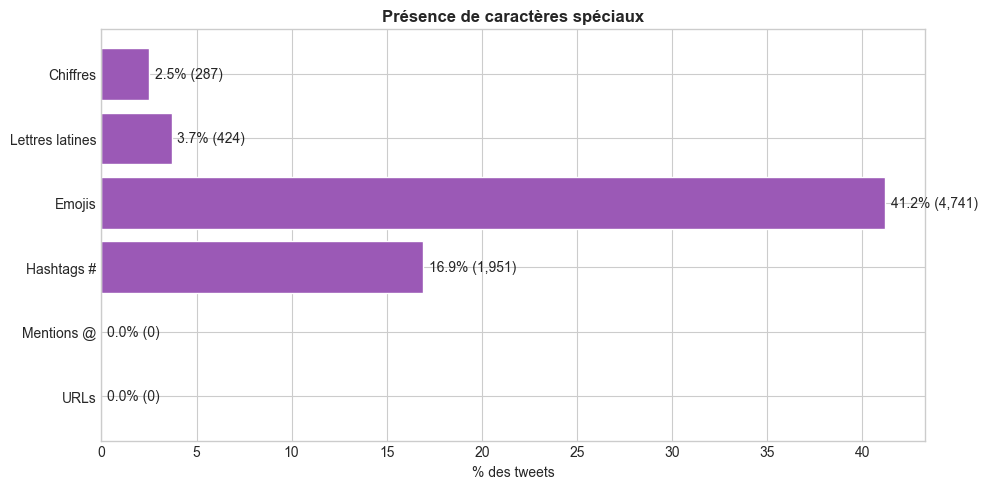

In [ ]:
df['has_url']     = df['text'].str.contains(r'http\S+|www\.\S+', regex=True)
df['has_mention'] = df['text'].str.contains(r'@\w+', regex=True)
df['has_hashtag'] = df['text'].str.contains(r'#\w+', regex=True)
df['has_emoji']   = df['text'].str.contains(r'[\U0001F600-\U0001F999]', regex=True)
df['has_latin']   = df['text'].str.contains(r'[a-zA-Z]', regex=True)
df['has_numbers'] = df['text'].str.contains(r'\d', regex=True)


features = ['has_url', 'has_mention', 'has_hashtag', 'has_emoji', 'has_latin', 'has_numbers']
labels   = ['URLs', 'Mentions @', 'Hashtags #', 'Emojis', 'Lettres latines', 'Chiffres']

counts = df[features].sum()
pcts   = (counts / len(df) * 100).round(1)

summary = pd.DataFrame({'count': counts, 'pct': pcts})
summary.index = labels
print(summary.to_string())


fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(labels, pcts.values, color='#9b59b6', edgecolor='white')
for i, (pct, cnt) in enumerate(zip(pcts.values, counts.values)):
    ax.text(pct + 0.3, i, f'{pct}% ({cnt:,})', va='center', fontsize=10)
ax.set_xlabel('% des tweets')
ax.set_title('Présence de caractères spéciaux', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}ds2_linguistic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Word Cloud par Classe

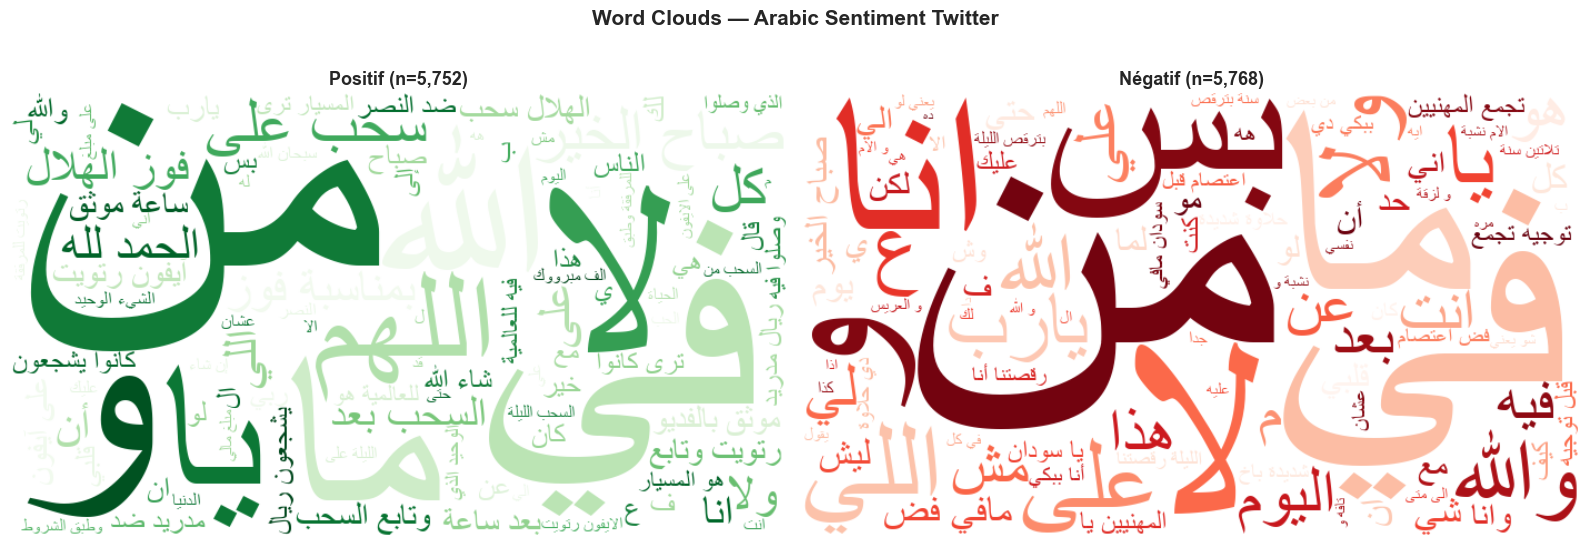

In [ ]:
def prepare_arabic_text(text):
    text = re.sub(r'http\S+|@\w+|#\w+', '', str(text))
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (lbl, cmap, title) in enumerate(zip([1, 0], ['Greens', 'Reds'], ['Positif', 'Négatif'])):
    corpus = ' '.join([
        prepare_arabic_text(t)
        for t in df[df['label'] == lbl]['text']
    ])
    wc = WordCloud(
        width=700, height=400,
        background_color='white',
        colormap=cmap,
        max_words=100,
        font_path='C:/Windows/Fonts/arial.ttf'
    ).generate(corpus)

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'{title} (n={len(df[df["label"]==lbl]):,})', fontsize=13, fontweight='bold')

plt.suptitle('Word Clouds — Arabic Sentiment Twitter', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}ds2_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Résumé & Conclusions

In [ ]:
maxlen = int(np.percentile(df['word_count'], 95))

print('=' * 55)
print('   RÉSUMÉ EDA — DATASET 2 ARABIC SENTIMENT TWITTER')
print('=' * 55)
print(f"""
DATASET
  Total tweets        : {len(df):,}
  Nombre de classes   : {df['label'].nunique()} (Positif / Négatif)
  Ratio déséquilibre  : {df['label'].value_counts().max() / df['label'].value_counts().min():.2f}x

LONGUEUR DES TWEETS
  Moyenne             : {df['word_count'].mean():.0f} mots
  Médiane             : {df['word_count'].median():.0f} mots
  Max                 : {df['word_count'].max()} mots
  → maxlen padding    : {maxlen} mots (95e percentile)

QUALITÉ
  Doublons            : {df.duplicated(subset='text').sum():,} ({df.duplicated(subset='text').mean()*100:.1f}%)
  Tweets +50 mots     : {(df['word_count'] > 50).sum()}
  Emojis              : {df['has_emoji'].sum():,} ({df['has_emoji'].mean()*100:.1f}%)
  Hashtags            : {df['has_hashtag'].sum():,} ({df['has_hashtag'].mean()*100:.1f}%)

Next step sera
  → Supprimer doublons et tweets corrompus
  → Supprimer emojis, hashtags, lettres latines
  → Normaliser les alef, supprimer tashkil + tatweel
  → Supprimer stopwords arabes
  → maxlen = {maxlen}
""")
print('=' * 55)

df.to_csv('../data/processed/ds2_eda.csv', index=False)
print('Sauvegardé : data/processed/ds2_eda.csv')

   RÉSUMÉ EDA — DATASET 2 ARABIC SENTIMENT TWITTER

DATASET
  Total tweets        : 11,520
  Nombre de classes   : 2 (Positif / Négatif)
  Ratio déséquilibre  : 1.00x

LONGUEUR DES TWEETS
  Moyenne             : 13 mots
  Médiane             : 13 mots
  Max                 : 813 mots
  → maxlen padding    : 24 mots (95e percentile)

QUALITÉ
  Doublons            : 2,703 (23.5%)
  Tweets +50 mots     : 12
  Emojis              : 4,741 (41.2%)
  Hashtags            : 1,951 (16.9%)

Next step sera
  → Supprimer doublons et tweets corrompus
  → Supprimer emojis, hashtags, lettres latines
  → Normaliser les alef, supprimer tashkil + tatweel
  → Supprimer stopwords arabes
  → maxlen = 24

Sauvegardé : data/processed/ds2_eda.csv


# Sprint 2 — Prétraitement des Données (Arabe)
---

## 0. Imports & Chargement

In [ ]:
import pandas as pd
import numpy as np
import re
import os
import json
import warnings
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

DATA_PATH      = '../data/raw/'
PROCESSED_PATH = '../data/processed/'
os.makedirs(PROCESSED_PATH, exist_ok=True)

df = pd.read_csv(PROCESSED_PATH + 'ds2_eda.csv')

print(f'Dataset chargé : {len(df):,} tweets')
print(f'Colonnes : {list(df.columns)}')
df.head(3)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Dataset chargé : 11,520 tweets
Colonnes : ['label_raw', 'text', 'label', 'label_name', 'word_count', 'char_count', 'has_url', 'has_mention', 'has_hashtag', 'has_emoji', 'has_latin', 'has_numbers']


,label_raw,text,label,label_name,word_count,char_count,has_url,has_mention,has_hashtag,has_emoji,has_latin,has_numbers
0,pos,#مسابقة والجائزة 💰 / من أول من فتق لسانه بالعر...,1,Positif,18,107,False,False,True,False,False,False
1,neg,❥↓🌿🍥 ما لأبن أدم والفخر اوله نطفه وأخره جيفه و...,0,Négatif,22,107,False,False,True,False,False,False
2,pos,"✨ لاتحزن ودع القلق,يستجيب لك الكريم هو يأخرها ...",1,Positif,21,116,False,False,False,False,False,False


## 1. Nettoyage

In [ ]:
def clean_arabic(text):
    text = str(text)
    # Supprimer URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Supprimer mentions @ et hashtags # et remplace _ par espace
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'_', ' ', text)
    # Supprimer emojis et symboles
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)
    # Suppression des virgules 
    text = re.sub(r'[،,؛;:.!?]', '', text)
    # Supprimer chiffres
    text = re.sub(r'\d+', '', text)
    # Supprimer espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_arabic)

# Vérification
print('Avant :')
print(df['text'].iloc[6])
print('\nAprès :')
print(df['text_clean'].iloc[6])

df.head()

Avant :
بمناسبة فوز الهلال .. 💙 سحب على آيفون XR📱 رتويت وتابع - السحب بعد ساعة موثق بالفديو 💪

Après :
بمناسبة فوز الهلال سحب على آيفون رتويت وتابع السحب بعد ساعة موثق بالفديو


,label_raw,text,label,label_name,word_count,char_count,has_url,has_mention,has_hashtag,has_emoji,has_latin,has_numbers,text_clean
0,pos,#مسابقة والجائزة 💰 / من أول من فتق لسانه بالعر...,1,Positif,18,107,False,False,True,False,False,False,مسابقة والجائزة من أول من فتق لسانه بالعربية ؟...
1,neg,❥↓🌿🍥 ما لأبن أدم والفخر اوله نطفه وأخره جيفه و...,0,Négatif,22,107,False,False,True,False,False,False,ما لأبن أدم والفخر اوله نطفه وأخره جيفه ولا ير...
2,pos,"✨ لاتحزن ودع القلق,يستجيب لك الكريم هو يأخرها ...",1,Positif,21,116,False,False,False,False,False,False,لاتحزن ودع القلقيستجيب لك الكريم هو يأخرها لوق...
3,neg,بيي الله يستر طلعتي من الدوام سيارتي وايد نازل...,0,Négatif,12,59,False,False,False,True,False,False,بيي الله يستر طلعتي من الدوام سيارتي وايد نازل...
4,neg,تلاتين سنة بترقص .. الليلة رقصتنا أنا ببكي 😭 د...,0,Négatif,13,63,False,False,False,True,False,False,تلاتين سنة بترقص الليلة رقصتنا أنا ببكي دي حلا...


## 2. Normalisation Arabe

In [ ]:
def normalize_arabic(text):
    # Normaliser les alef
    text = re.sub(r'[أإآ]', 'ا', text)
    # Normaliser teh marbuta
    text = re.sub(r'ة', 'ه', text)
    # Normaliser alef ma9soura
    text = re.sub(r'ى', 'ي', text)
    # Supprimer tatweel
    text = re.sub(r'ـ', '', text)
    # Supprimer tashkil (diacritiques)
    text = re.sub(r'[\u064B-\u065F]', '', text)
    return text

df['text_clean'] = df['text_clean'].apply(normalize_arabic)

# Vérification
print('Avant normalisation :')
print(df['text'].iloc[1])
print('\nAprès normalisation :')
print(df['text_clean'].iloc[1])


Avant normalisation :
❥↓🌿🍥 ما لأبن أدم والفخر اوله نطفه وأخره جيفه ولا يرزق نفسه ولا يدفع حتفه {قال الأمام علي ع }♡💙🕊 #أتعبتني 💔…

Après normalisation :
ما لابن ادم والفخر اوله نطفه واخره جيفه ولا يرزق نفسه ولا يدفع حتفه قال الامام علي ع اتعبتني


## 3. Tokenisation & Stopwords

In [ ]:
negation_words = {
    'لا', 'ليس', 'ليست', 'ليسوا', 'لست', 'لسنا', 'لستم', 'لستن',
    'لم', 'لما', 'لن', 'ما', 'غير', 'بدون', 'بلا', 'أبدا', 'قط'
}

arabic_stopwords = set(normalize_arabic(w) for w in stopwords.words('arabic'))
arabic_stopwords = arabic_stopwords - negation_words

def tokenize_and_remove_stopwords(text):
    tokens = text.split()
    tokens = [t for t in tokens if t not in arabic_stopwords]
    return ' '.join(tokens)

df['text_clean'] = df['text_clean'].apply(tokenize_and_remove_stopwords)

before = len(df)
df = df[df['text_clean'].str.strip() != ''].reset_index(drop=True)
after = len(df)

print(f'Tweets supprimés : {before - after}')
print(f'Total restant    : {after:,}')

print('\nAvant :')
print(df['text'].iloc[106])
print('\nAprès :')
print(df['text_clean'].iloc[106])

Tweets supprimés : 30
Total restant    : 11,490

Avant :
لا جد امطار الرياض تخوف امس واحد كان بيموت 😥

Après :
لا جد امطار الرياض تخوف بيموت


## 4. Suppression Doublons & Tweets Corrompus

In [ ]:
before = len(df)

df = df.drop_duplicates(subset='text_clean').reset_index(drop=True)
df = df[df['word_count'] <= 50].reset_index(drop=True)

after = len(df)

print(f'Avant     : {before:,} tweets')
print(f'Après     : {after:,} tweets')
print(f'Supprimés : {before - after:,}')

Avant     : 11,490 tweets
Après     : 8,622 tweets
Supprimés : 2,868


## 5. Vectorisation TF-IDF

In [ ]:
tfidf = TfidfVectorizer(max_features=10000)
X_tfidf = tfidf.fit_transform(df['text_clean'])

print(f'Shape matrice TF-IDF : {X_tfidf.shape}')
print(f'Vocabulaire size     : {len(tfidf.vocabulary_)}')

# Sauvegarder le vectoriseur
with open(PROCESSED_PATH + 'tfidf_vectorizer_ds2.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print('Sauvegardé : tfidf_vectorizer_ds2.pkl')

Shape matrice TF-IDF : (8622, 10000)
Vocabulaire size     : 10000
Sauvegardé : tfidf_vectorizer_ds2.pkl


In [ ]:
maxlen = int(np.percentile(df['word_count'], 95))
print(f'maxlen : {maxlen}')

maxlen : 24


## 6. Séquences & Padding

In [ ]:
VOCAB_SIZE = 10000
MAXLEN     = int(np.percentile(df['word_count'], 95))

# Créer et entraîner le tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df['text_clean'])

# Convertir en séquences
sequences = tokenizer.texts_to_sequences(df['text_clean'])

# Padding
X = pad_sequences(sequences, maxlen=MAXLEN, padding='post', truncating='post')

print(f'Shape final : {X.shape}')
print(f'Tweet nettoyé   : {df["text_clean"].iloc[106]}')
print(f'Exemple séquence brute  : {sequences[106]}')
print(f'Exemple après padding   : {X[106]}')

# Sauvegarder le tokenizer
with open(PROCESSED_PATH + 'keras_tokenizer_ds2.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print('Sauvegardé : keras_tokenizer_ds2.pkl')

Shape final : (8622, 24)
Tweet nettoyé   : سلامه الجميل سلامه مي يارب ماتشوفي شر حبيبتي الله يشفيكي ويعافيكي مرض ويحفظ
Exemple séquence brute  : [1143, 252, 1143, 2544, 9, 9138, 767, 559, 2, 5112, 9139, 858, 9140]
Exemple après padding   : [1143  252 1143 2544    9 9138  767  559    2 5112 9139  858 9140    0
    0    0    0    0    0    0    0    0    0    0]
Sauvegardé : keras_tokenizer_ds2.pkl


## 7. Split Train / Val / Test

In [ ]:
from sklearn.model_selection import train_test_split

y = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)
print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_test.shape}')

np.save(PROCESSED_PATH + 'X_train_pad_ds2.npy', X_train)
np.save(PROCESSED_PATH + 'X_val_pad_ds2.npy',   X_val)
np.save(PROCESSED_PATH + 'X_test_pad_ds2.npy',  X_test)
np.save(PROCESSED_PATH + 'y_train_ds2.npy',     y_train)
np.save(PROCESSED_PATH + 'y_val_ds2.npy',       y_val)
np.save(PROCESSED_PATH + 'y_test_ds2.npy',      y_test)

print('Tous les fichiers sauvegardés ')

Train : (6035, 24)
Val   : (1293, 24)
Test  : (1294, 24)
Tous les fichiers sauvegardés 


In [ ]:
df[['text_clean', 'label']].to_csv(PROCESSED_PATH + 'ds2_preprocessed.csv', index=False)
print('Sauvegardé : ds2_preprocessed.csv ✅')

Sauvegardé : ds2_preprocessed.csv ✅


## 8. Résumé & Sauvegarde des Paramètres

In [ ]:
params = {
    'vocab_size'   : VOCAB_SIZE,
    'maxlen'       : MAXLEN,
    'train_size'   : X_train.shape[0],
    'val_size'     : X_val.shape[0],
    'test_size'    : X_test.shape[0],
    'total_tweets' : len(df),
    'num_classes'  : 2
}

with open(PROCESSED_PATH + 'ds2_params.json', 'w') as f:
    json.dump(params, f, indent=4)

print('=' * 50)
print('   RÉSUMÉ SPRINT 2 — PREPROCESSING DS2')
print('=' * 50)
for k, v in params.items():
    print(f'  {k:<20} : {v}')
print('=' * 50)
print('Sauvegardé : ds2_params.json ✅')

   RÉSUMÉ SPRINT 2 — PREPROCESSING DS2
  vocab_size           : 10000
  maxlen               : 24
  train_size           : 6035
  val_size             : 1293
  test_size            : 1294
  total_tweets         : 8622
  num_classes          : 2
Sauvegardé : ds2_params.json ✅


# Sprint 3 — LSTM Baseline
---

## 0. Imports & Chargement

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

PROCESSED_PATH = '../data/processed/'
RESULTS_PATH   = '../results/scores/'
FIGURES_PATH   = '../results/figures/'
os.makedirs(RESULTS_PATH, exist_ok=True)

# Charger les paramètres
with open(PROCESSED_PATH + 'ds2_params.json') as f:
    params = json.load(f)

VOCAB_SIZE  = params['vocab_size']
MAXLEN      = params['maxlen']
NUM_CLASSES = params['num_classes']

X_train = np.load(PROCESSED_PATH + 'X_train_pad_ds2.npy')
X_val   = np.load(PROCESSED_PATH + 'X_val_pad_ds2.npy')
X_test  = np.load(PROCESSED_PATH + 'X_test_pad_ds2.npy')
y_train = np.load(PROCESSED_PATH + 'y_train_ds2.npy')
y_val   = np.load(PROCESSED_PATH + 'y_val_ds2.npy')
y_test  = np.load(PROCESSED_PATH + 'y_test_ds2.npy')

print(f'VOCAB_SIZE : {VOCAB_SIZE}')
print(f'MAXLEN     : {MAXLEN}')
print(f'X_train    : {X_train.shape}')
print(f'X_val      : {X_val.shape}')
print(f'X_test     : {X_test.shape}')

VOCAB_SIZE : 10000
MAXLEN     : 24
X_train    : (6035, 24)
X_val      : (1293, 24)
X_test     : (1294, 24)


## 1. Construction du modèle LSTM

In [ ]:
import sys
sys.path.append('../src/models')
from lstm_model import build_lstm_model

model = build_lstm_model(
    vocab_size     = VOCAB_SIZE,
    maxlen         = MAXLEN,
    n_classes      = NUM_CLASSES,
    embedding_dim  = 128,
    lstm_units     = 64,
    dropout        = 0.2
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 2. Entraînement

In [ ]:
import time

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('../results/best_model_ds2.keras', save_best_only=True, monitor='val_loss')
]

start = time.time()

history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs     = 20,
    batch_size = 32,
    callbacks  = callbacks,
    verbose    = 1
)

training_time = time.time() - start
print(f'\nTemps entraînement : {training_time:.1f}s')

Epoch 1/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.5039 - loss: 0.6937 - val_accuracy: 0.5398 - val_loss: 0.6919
Epoch 2/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6418 - loss: 0.6474 - val_accuracy: 0.6326 - val_loss: 0.6635
Epoch 3/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7828 - loss: 0.5019 - val_accuracy: 0.6195 - val_loss: 0.7540
Epoch 4/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8484 - loss: 0.3690 - val_accuracy: 0.6172 - val_loss: 0.9001
Epoch 5/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8910 - loss: 0.2752 - val_accuracy: 0.6056 - val_loss: 1.0292

Temps entraînement : 19.9s


## 3. Évaluation & Métriques

In [ ]:

y_pred_proba = model.predict(X_test)
print(X_test[0])
print(y_pred_proba[0])
y_pred = np.argmax(y_pred_proba, axis=1)

accuracy  = accuracy_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred, average='macro')
precision = precision_score(y_test, y_pred, average='macro')
recall    = recall_score(y_test, y_pred, average='macro')

print('=' * 45)
print('   RÉSULTATS BASELINE — DS2 ARABIC')
print('=' * 45)
print(f'  Accuracy  : {accuracy:.4f}')
print(f'  F1 macro  : {f1:.4f}')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  Temps (s) : {training_time:.1f}')
print(f'  Features  : {VOCAB_SIZE}')
print('=' * 45)

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
[  61   35  187 9083 9084   61  764  187 3417 2531 9085  438 9086   61
  764  187 5087 5088    0    0    0    0    0    0]
[0.44202536 0.55797464]
   RÉSULTATS BASELINE — DS2 ARABIC
  Accuracy  : 0.6337
  F1 macro  : 0.6240
  Precision : 0.6449
  Recall    : 0.6314
  Temps (s) : 19.9
  Features  : 10000


## 4. Visualisations

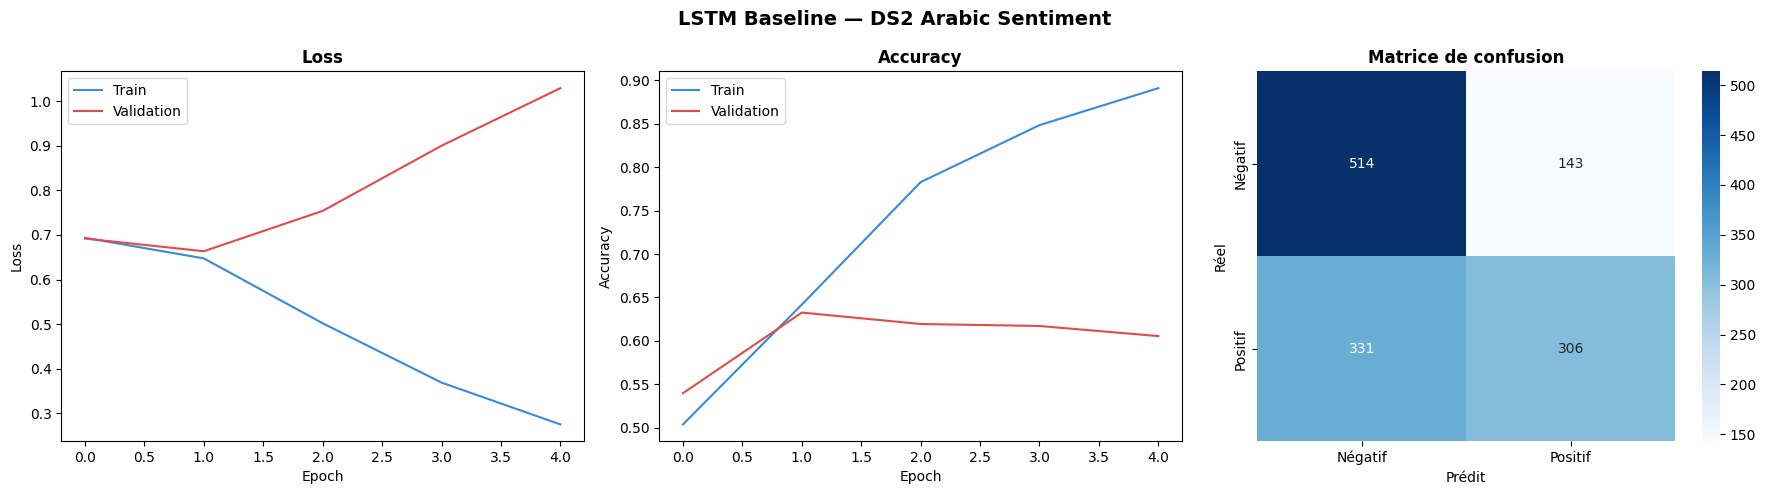

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Courbe Loss
axes[0].plot(history.history['loss'], label='Train', color='#378ADD')
axes[0].plot(history.history['val_loss'], label='Validation', color='#E24B4A')
axes[0].set_title('Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Courbe Accuracy
axes[1].plot(history.history['accuracy'], label='Train', color='#378ADD')
axes[1].plot(history.history['val_accuracy'], label='Validation', color='#E24B4A')
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Négatif', 'Positif'],
            yticklabels=['Négatif', 'Positif'], ax=axes[2])
axes[2].set_title('Matrice de confusion', fontweight='bold')
axes[2].set_xlabel('Prédit')
axes[2].set_ylabel('Réel')

plt.suptitle('LSTM Baseline — DS2 Arabic Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}ds2_baseline_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Sauvegarde des Résultats

In [ ]:
results = {
    'methode'   : 'Baseline',
    'features'  : VOCAB_SIZE,
    'accuracy'  : round(accuracy, 4),
    'f1_macro'  : round(f1, 4),
    'precision' : round(precision, 4),
    'recall'    : round(recall, 4),
    'temps_s'   : round(training_time, 1)
}

pd.DataFrame([results]).to_csv(RESULTS_PATH + 'baseline_ds2.csv', index=False)
print(pd.DataFrame([results]).to_string(index=False))

 methode  features  accuracy  f1_macro  precision  recall  temps_s
Baseline     10000    0.6337     0.624     0.6449  0.6314     19.9



# Interprétation — LSTM Baseline DS2 Arabic Sentiment

## Performance Générale

| Métrique  | Valeur |
|-----------|--------|
| Accuracy  | 63.37% |
| F1 macro  | 62.40% |
| Precision | 64.49% |
| Recall    | 63.14% |
| Temps     | 19.9s  |
| Features  | 10,000 |

Le modèle baseline atteint une accuracy de **63.37%**, ce qui représente
une performance modeste mais attendue pour une configuration sans
sélection d'attributs.

## Analyse de l'Overfitting

Les courbes d'apprentissage révèlent un overfitting sévère :

- Train accuracy : **89%** vs Val accuracy : **60%** → gap de 29%
- Train loss : **0.27** (baisse) vs Val loss : **1.03** (monte)

L'Early Stopping s'est déclenché à l'Epoch 5, ce qui confirme que
le modèle mémorise les données d'entraînement au lieu d'apprendre
des patterns généralisables.

## Analyse de la Matrice de Confusion

| | Prédit Négatif | Prédit Positif |
|---|---|---|
| Réel Négatif | **514** ✅ | 143 ❌ |
| Réel Positif | **331** ❌ | 306 ✅ |

Le modèle présente un biais vers la classe **Négatif** :
- Taux de bonne classification Négatif : 78.2%
- Taux de bonne classification Positif : 48.0%

Les tweets positifs sont mal classés dans 51.9% des cas.

## Causes Identifiées

1. **Dataset limité** : seulement 8,622 tweets après nettoyage
2. **maxlen = 24** : séquences courtes → perte de contexte
3. **Bruit résiduel** : mots collés aux stopwords (و، يا...)
4. **Pas de feature selection** : 10,000 features dont beaucoup inutiles

## Perspectives

La feature selection (Mutual Information et Algorithme Génétique)
devrait réduire le bruit dans le vocabulaire et améliorer la
généralisation du modèle en se concentrant sur les features
les plus discriminantes.
"""

from IPython.display import Markdown
display(Markdown(interpretation))

# Sprint 4 — Feature Selection par Mutual Information
---

## 0. Imports & Chargement

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import os
import time
import warnings
import arabic_reshaper
from bidi.algorithm import get_display
import arabic_reshaper
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'  
warnings.filterwarnings('ignore')

from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import sys
sys.path.append('../src/models')
from lstm_model import build_lstm_model

PROCESSED_PATH = '../data/processed/'
RESULTS_PATH   = '../results/scores/'
FIGURES_PATH   = '../results/figures/'
os.makedirs(RESULTS_PATH, exist_ok=True)

with open(PROCESSED_PATH + 'ds2_params.json') as f:
    params = json.load(f)

VOCAB_SIZE  = params['vocab_size']
MAXLEN      = params['maxlen']
NUM_CLASSES = params['num_classes']

X_train = np.load(PROCESSED_PATH + 'X_train_pad_ds2.npy')
X_val   = np.load(PROCESSED_PATH + 'X_val_pad_ds2.npy')
X_test  = np.load(PROCESSED_PATH + 'X_test_pad_ds2.npy')
y_train = np.load(PROCESSED_PATH + 'y_train_ds2.npy')
y_val   = np.load(PROCESSED_PATH + 'y_val_ds2.npy')
y_test  = np.load(PROCESSED_PATH + 'y_test_ds2.npy')

with open(PROCESSED_PATH + 'tfidf_vectorizer_ds2.pkl', 'rb') as f:
    tfidf = pickle.load(f)

with open(PROCESSED_PATH + 'keras_tokenizer_ds2.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

df = pd.read_csv(PROCESSED_PATH + 'ds2_preprocessed.csv')

print(f'Données chargées ✅')
print(f'X_train : {X_train.shape}')
print(f'TF-IDF vocab : {len(tfidf.vocabulary_)}')

Données chargées ✅
X_train : (6035, 24)
TF-IDF vocab : 10000


## 1. Calcul des Scores MI

In [ ]:
# Recalculer TF-IDF sur le train seulement
df_train = df.iloc[:len(y_train)]
X_tfidf_train = tfidf.transform(df_train['text_clean'])

# Calculer les scores MI
print('Calcul des scores MI...')
mi_scores = mutual_info_classif(X_tfidf_train, y_train, random_state=42)

# Créer un DataFrame des scores
vocab = tfidf.get_feature_names_out()
mi_df = pd.DataFrame({'mot': vocab, 'mi_score': mi_scores})
mi_df = mi_df.sort_values('mi_score', ascending=False).reset_index(drop=True)

print(f'Top 10 mots les plus informatifs :')
print(mi_df.head(10).to_string(index=False))

Calcul des scores MI...
Top 10 mots les plus informatifs :
   mot  mi_score
  الله  0.069911
    لا  0.052863
    ما  0.052654
 اللهم  0.030759
  اللي  0.026897
 والله  0.020285
 الخير  0.018794
  يارب  0.017953
   يوم  0.016772
الهلال  0.015937


## Bloc 2 — Visualisation Top 50 Mots MI

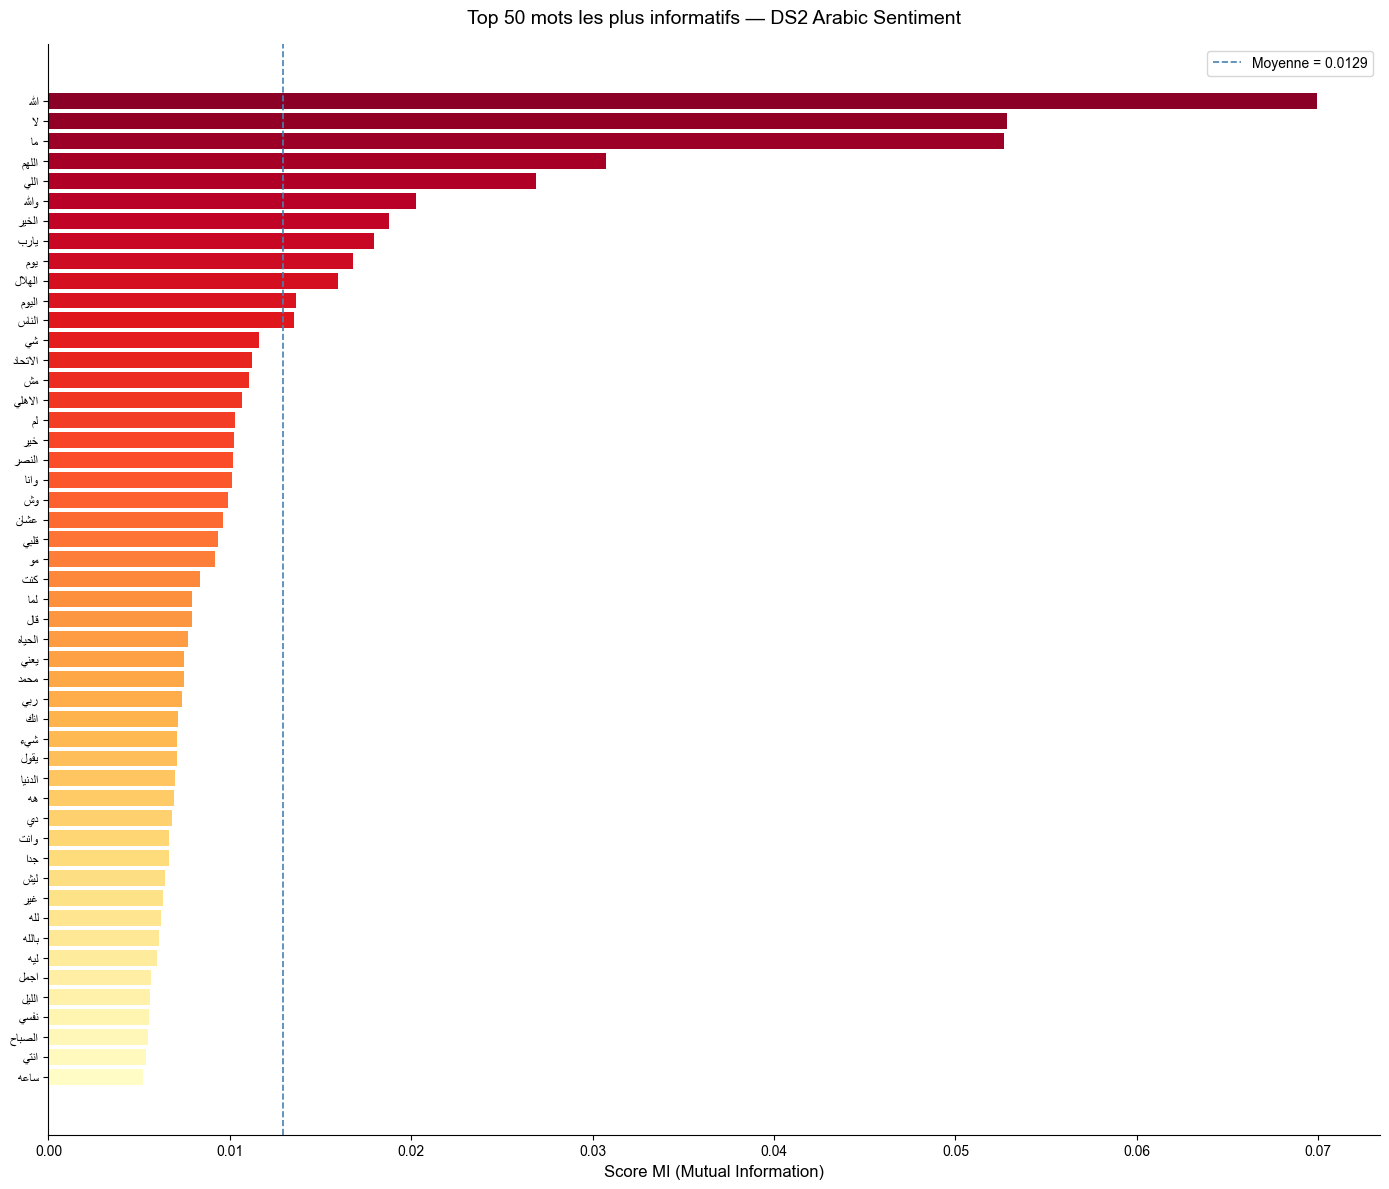

In [ ]:

top50 = mi_df.head(50).copy()

top50['mot_display'] = top50['mot'].apply(
    lambda w: get_display(arabic_reshaper.reshape(w))
)

fig, ax = plt.subplots(figsize=(14, 12))
palette = sns.color_palette("YlOrRd", n_colors=50)[::-1]

ax.barh(range(50), top50['mi_score'].values, color=palette)
ax.set_yticks(range(50))
ax.set_yticklabels(top50['mot_display'].values, fontsize=9, fontfamily='Arial')
ax.invert_yaxis()
ax.set_xlabel('Score MI (Mutual Information)', fontsize=12)
ax.set_title('Top 50 mots les plus informatifs — DS2 Arabic Sentiment', fontsize=14, pad=15)
ax.axvline(x=top50['mi_score'].mean(), color='steelblue',
           linestyle='--', linewidth=1.2,
           label=f"Moyenne = {top50['mi_score'].mean():.4f}")
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'mi_top50_ds2.png', dpi=150, bbox_inches='tight')
plt.show()


## Helper — Fonctions MI remapping

In [ ]:
def build_mi_sequences(k, mi_df, tokenizer, X_train, X_val, X_test):
    top_k_words = mi_df.head(k)['mot'].tolist()
    
    
    new_vocab = {word: idx+1 for idx, word in enumerate(top_k_words)}
    
    old_to_new = {}
    for word, new_idx in new_vocab.items():
        old_idx = tokenizer.word_index.get(word)
        if old_idx is not None:
            old_to_new[old_idx] = new_idx
    
    print(f"k={k} | mots remappés : {len(old_to_new)}/{k}")
    
    def remap(X):
        X_new = np.zeros_like(X)
        for old_idx, new_idx in old_to_new.items():
            X_new[X == old_idx] = new_idx
        return X_new
    
    return remap(X_train), remap(X_val), remap(X_test), len(old_to_new)+1


def train_mi_remapped(k, mi_df, tokenizer, X_train, X_val, X_test,
                      y_train, y_val, y_test):
    
    Xtr, Xvl, Xts, new_vocab_size = build_mi_sequences(
        k, mi_df, tokenizer, X_train, X_val, X_test
    )
    
    model = build_lstm_model(
        vocab_size=new_vocab_size,
        maxlen=MAXLEN,
        n_classes=NUM_CLASSES
    )
    
    es = EarlyStopping(monitor='val_loss', patience=3,
                       restore_best_weights=True, verbose=1)
    
    t0 = time.time()
    history = model.fit(
        Xtr, y_train,
        validation_data=(Xvl, y_val),
        epochs=20,
        batch_size=64,
        callbacks=[es],
        verbose=1
    )
    elapsed = round(time.time() - t0, 1)
    
    y_pred = np.argmax(model.predict(Xts, verbose=0), axis=1)
    
    results = {
        'method'   : f'MI k={k}',
        'features' : k,
        'accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'f1_macro' : round(f1_score(y_test, y_pred, average='macro'), 4),
        'precision': round(precision_score(y_test, y_pred, average='macro'), 4),
        'recall'   : round(recall_score(y_test, y_pred, average='macro'), 4),
        'time_s'   : elapsed
    }
    
    for key, val in results.items():
        print(f"{key:<12} : {val}")
    
    return results, history, model



## Bloc 3 — LSTM avec MI k=300

In [ ]:
results_300, history_300, model_300 = train_mi_remapped(
    300, mi_df, tokenizer, X_train, X_val, X_test, y_train, y_val, y_test
)

k=300 | mots remappés : 300/300
Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.5032 - loss: 0.6936 - val_accuracy: 0.5073 - val_loss: 0.6954
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5249 - loss: 0.6918 - val_accuracy: 0.5770 - val_loss: 0.6799
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5360 - loss: 0.6877 - val_accuracy: 0.5336 - val_loss: 0.6898
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5877 - loss: 0.6660 - val_accuracy: 0.5847 - val_loss: 0.6843
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6204 - loss: 0.6534 - val_accuracy: 0.5986 - val_loss: 0.6800
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.
method       : MI k=300
features     : 300
accuracy     : 0.5641
f1_macro     : 0.4998
precision    : 0.6157
recall       : 0.5587
time_s       : 15.2


## Bloc 4 — LSTM avec MI k=700

In [ ]:
results_700, history_700, model_700 = train_mi_remapped(
    700, mi_df, tokenizer, X_train, X_val, X_test, y_train, y_val, y_test
)

k=700 | mots remappés : 700/700
Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.5024 - loss: 0.6936 - val_accuracy: 0.4927 - val_loss: 0.6931
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5534 - loss: 0.6808 - val_accuracy: 0.5623 - val_loss: 0.6877
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6250 - loss: 0.6515 - val_accuracy: 0.5986 - val_loss: 0.6749
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6449 - loss: 0.6355 - val_accuracy: 0.6025 - val_loss: 0.6670
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6724 - loss: 0.6144 - val_accuracy: 0.5916 - val_loss: 0.6780
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6814 - loss: 0.6054 - val_accuracy: 0.6040 - val_loss: 0.6781
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6883 - loss: 0.6026 - val_accuracy: 0.5978 - val_loss: 0.6923
Epoch 7: early stopping
Restoring model weights from the end of the best epoch:

## Bloc 5 — LSTM avec MI k=1500

In [ ]:
results_1500, history_1500, model_1500 = train_mi_remapped(
    1500, mi_df, tokenizer, X_train, X_val, X_test, y_train, y_val, y_test
)

k=1500 | mots remappés : 1500/1500
Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.5135 - loss: 0.6939 - val_accuracy: 0.5073 - val_loss: 0.6944
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.5112 - loss: 0.6931 - val_accuracy: 0.4927 - val_loss: 0.6924
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.5950 - loss: 0.6640 - val_accuracy: 0.5955 - val_loss: 0.6685
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.6669 - loss: 0.6188 - val_accuracy: 0.6187 - val_loss: 0.6992
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.7001 - loss: 0.5837 - val_accuracy: 0.6203 - val_loss: 0.6738
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.7203 - loss: 0.5567 - val_accuracy: 0.6048 - val_loss: 0.6785
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
method       : MI k=1500
features     : 1500
accuracy     : 0.5989
f1_macro     : 0.5549
precision    : 0.651
recall   

## Bloc 6 — Comparaison des résultats MI

   method  features  accuracy  f1_macro  precision  recall  time_s
 Baseline     10000    0.6337    0.6240     0.6449  0.6314    19.9
 MI k=300       300    0.5641    0.4998     0.6157  0.5587    15.2
 MI k=700       700    0.6167    0.6030     0.6304  0.6140    19.9
MI k=1500      1500    0.5989    0.5549     0.6510  0.5942    25.4


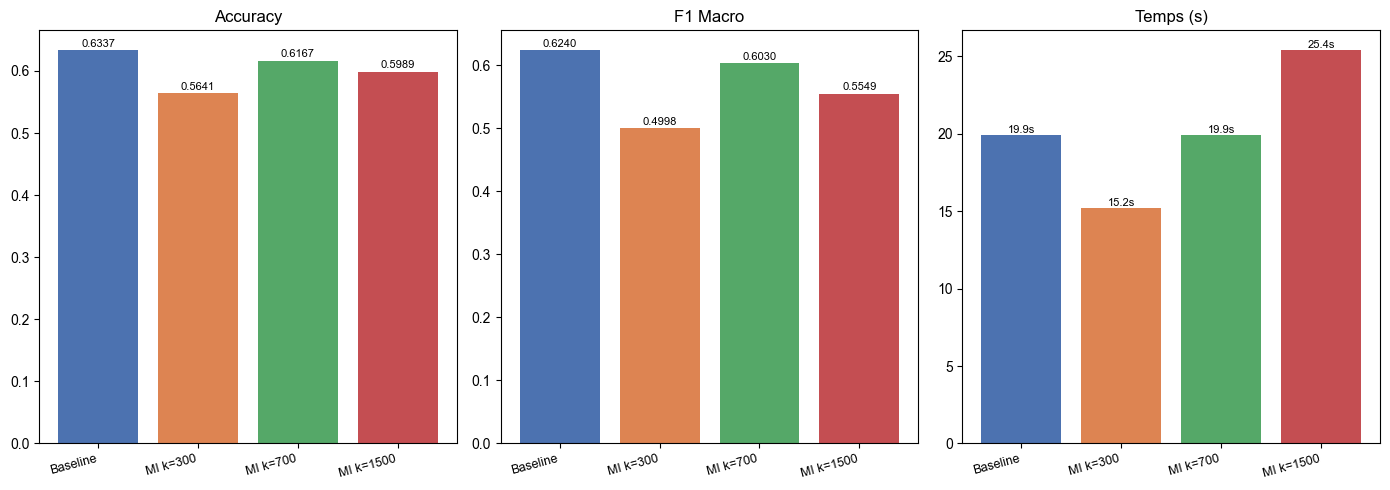

In [ ]:
baseline_row = {
    'method'   : 'Baseline',
    'features' : 10000,
    'accuracy' : 0.6337,
    'f1_macro' : 0.6240,
    'precision': 0.6449,
    'recall'   : 0.6314,
    'time_s'   : 19.9
}

all_results = pd.DataFrame([baseline_row, results_300, results_700, results_1500])
print(all_results.to_string(index=False))
all_results.to_csv(RESULTS_PATH + 'mi_comparison_ds2.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['accuracy', 'f1_macro', 'time_s']
titles  = ['Accuracy', 'F1 Macro', 'Temps (s)']
colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(all_results['method'], all_results[metric], color=colors)
    ax.set_title(title)
    ax.set_xticklabels(all_results['method'], rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, all_results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{val:.4f}' if metric != 'time_s' else f'{val:.1f}s',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_PATH + 'mi_comparison_ds2.png', dpi=150, bbox_inches='tight')
plt.show()

## Bloc 7 — Interprétation

### Résultats MI Feature Selection — DS2 Arabic Sentiment

| Méthode | Features | Accuracy | F1 Macro | Temps |
|---------|----------|----------|----------|-------|
| Baseline | 10 000 | 0.6337 | 0.6240 | 19.9s |
| MI k=300 | 300 | 0.5641 | 0.4998 | 15.2s |
| MI k=700 | 700 | 0.6167 | 0.6030 | 19.9s |
| MI k=1500 | 1500 | 0.5989 | 0.5549 | 25.4s |

---

### Analyse des résultats

**Le Baseline reste le meilleur** sur accuracy (0.6337) et F1 macro (0.6240).
Aucune valeur de k ne réussit à le dépasser.

**k=700 est le meilleur parmi les MI** avec accuracy=0.6167 et F1=0.6030, très proche du baseline.

**k=300 est le pire** : trop peu de mots, le LSTM n'a pas assez d'information pour apprendre, F1 tombe à 0.4998 (presque aléatoire).

**k=1500 moins bon que k=700** : surprenant, mais le LSTM avec un vocabulaire plus grand prend plus de temps à converger et l'Early Stopping l'arrête trop tôt (25.4s, plus lent).

---

### Pourquoi MI ne bat pas le Baseline ?

La MI sélectionne les mots selon leur score **TF-IDF individuel**, sans tenir compte de l'ordre des mots. Mais le LSTM est un modèle **séquentiel** — l'ordre des mots compte. En réduisant le vocabulaire, on perd des mots qui sont peut-être peu informatifs seuls, mais importants dans leur contexte séquentiel.

Exemple : le mot **يوم** (jour) a un score MI modeste, mais dans la séquence "يوم سعيد" (bonne journée) il est crucial pour le sentiment positif.

---

### Overfitting

Le problème d'overfitting du Baseline (Train 89% vs Val 60%) **persiste avec MI**. La réduction de vocabulaire ne suffit pas à régulariser le modèle. La sélection MI agit sur les features TF-IDF, pas directement sur la capacité du LSTM.

---

### Perspectives — Sprint 5 (Algorithme Génétique)

L'Algorithme Génétique va chercher directement **la combinaison optimale de features** en maximisant la performance du LSTM. Contrairement à MI qui classe les mots indépendamment, le GA teste des **sous-ensembles entiers** — ce qui est théoriquement plus adapté à un modèle séquentiel.

# Sprint 5 — Feature Selection par Algorithme Génétique (MI+GA)
---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

PROCESSED_PATH = '/content/drive/MyDrive/text_mining_ds2/processed/'
MODELS_PATH    = '/content/drive/MyDrive/text_mining_ds2/models/'

print("Fichiers processed :")
for f in os.listdir(PROCESSED_PATH):
    print(f)

print("\nFichiers models :")
for f in os.listdir(MODELS_PATH):
    print(f)

Fichiers processed :
ds2_eda.csv
tfidf_vectorizer_ds2.pkl
y_test_ds2.npy
X_train_pad_ds2.npy
X_val_pad_ds2.npy
ds2_preprocessed.csv
y_train_ds2.npy
keras_tokenizer_ds2.pkl
y_val_ds2.npy
X_test_pad_ds2.npy
ds2_params.json

Fichiers models :
lstm_model.py
__pycache__


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import os
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
import sys
sys.path.append(MODELS_PATH)
from lstm_model import build_lstm_model

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tensorflow.keras.callbacks import EarlyStopping

print("Imports OK")
print("GPU dispo :", len(tf.config.list_physical_devices('GPU')) > 0)

Imports OK
GPU dispo : True


## Bloc 0 — Imports & Chargement des données

In [ ]:
with open(PROCESSED_PATH + 'ds2_params.json') as f:
    params = json.load(f)

VOCAB_SIZE  = params['vocab_size']
MAXLEN      = params['maxlen']
NUM_CLASSES = params['num_classes']

X_train = np.load(PROCESSED_PATH + 'X_train_pad_ds2.npy')
X_val   = np.load(PROCESSED_PATH + 'X_val_pad_ds2.npy')
X_test  = np.load(PROCESSED_PATH + 'X_test_pad_ds2.npy')
y_train = np.load(PROCESSED_PATH + 'y_train_ds2.npy')
y_val   = np.load(PROCESSED_PATH + 'y_val_ds2.npy')
y_test  = np.load(PROCESSED_PATH + 'y_test_ds2.npy')

with open(PROCESSED_PATH + 'tfidf_vectorizer_ds2.pkl', 'rb') as f:
    tfidf = pickle.load(f)

with open(PROCESSED_PATH + 'keras_tokenizer_ds2.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

df = pd.read_csv(PROCESSED_PATH + 'ds2_preprocessed.csv')

print(f"X_train : {X_train.shape}")
print(f"VOCAB_SIZE : {VOCAB_SIZE} | MAXLEN : {MAXLEN} | NUM_CLASSES : {NUM_CLASSES}")

X_train : (6035, 24)
VOCAB_SIZE : 10000 | MAXLEN : 24 | NUM_CLASSES : 2


## Bloc 1 — Calcul des scores MI (base pour le GA)

In [ ]:
from sklearn.feature_selection import mutual_info_classif

df_train = df.iloc[:len(y_train)]
X_tfidf_train = tfidf.transform(df_train['text_clean'])

print("Calcul des scores MI...")
mi_scores = mutual_info_classif(X_tfidf_train, y_train, random_state=42)

vocab = tfidf.get_feature_names_out()
mi_df = pd.DataFrame({'mot': vocab, 'mi_score': mi_scores})
mi_df = mi_df.sort_values('mi_score', ascending=False).reset_index(drop=True)

print("Top 10 mots les plus informatifs :")
print(mi_df.head(10).to_string(index=False))

Calcul des scores MI...
Top 10 mots les plus informatifs :
   mot  mi_score
  الله  0.069911
    لا  0.052863
    ما  0.052654
 اللهم  0.030759
  اللي  0.026897
 والله  0.020285
 الخير  0.018794
  يارب  0.017953
   يوم  0.016772
الهلال  0.015937


## Bloc 2 — Fonction fitness (LSTM)



In [ ]:
TOP_K_SEARCH = 1000
search_space = mi_df.head(TOP_K_SEARCH)['mot'].tolist()

def evaluate_individual(individual):
    selected = [search_space[i] for i, bit in enumerate(individual) if bit == 1]

    if len(selected) < 10:
        return (0.0,)

    new_vocab = {word: idx+1 for idx, word in enumerate(selected)}
    old_to_new = {}
    for word, new_idx in new_vocab.items():
        old_idx = tokenizer.word_index.get(word)
        if old_idx is not None:
            old_to_new[old_idx] = new_idx

    def remap(X):
        X_new = np.zeros_like(X)
        for old_idx, new_idx in old_to_new.items():
            X_new[X == old_idx] = new_idx
        return X_new

    Xtr = remap(X_train)
    Xvl = remap(X_val)
    vocab_size = len(old_to_new) + 1

    model = build_lstm_model(
        vocab_size=vocab_size,
        maxlen=MAXLEN,
        n_classes=NUM_CLASSES
    )

    es = EarlyStopping(monitor='val_loss', patience=2,
                       restore_best_weights=True, verbose=0)

    model.fit(
        Xtr, y_train,
        validation_data=(Xvl, y_val),
        epochs=5,
        batch_size=64,
        callbacks=[es],
        verbose=0
    )

    y_pred = np.argmax(model.predict(Xvl, verbose=0), axis=1)
    f1 = f1_score(y_val, y_pred, average='macro')
    return (f1,)

print("Fitness LSTM définie")
print("Chaque évaluation ≈ 15s sur GPU")


Fitness LSTM définie
Chaque évaluation ≈ 15s sur GPU


## Bloc 3 — Configuration DEAP

In [ ]:
from deap import base, creator, tools
import random

if 'FitnessMax' not in dir(creator):
    creator.create('FitnessMax', base.Fitness, weights=(1.0,))
if 'Individual' not in dir(creator):
    creator.create('Individual', list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register('attr_bool', np.random.randint, 0, 2)
toolbox.register('individual', tools.initRepeat,
                 creator.Individual, toolbox.attr_bool, n=TOP_K_SEARCH)
toolbox.register('population', tools.initRepeat, list, toolbox.individual)
toolbox.register('evaluate', evaluate_individual)
toolbox.register('mate',     tools.cxTwoPoint)
toolbox.register('mutate',   tools.mutFlipBit, indpb=0.01)
toolbox.register('select',   tools.selTournament, tournsize=3)

print("DEAP configuré")
print(f"Taille chromosome : {TOP_K_SEARCH} bits")

DEAP configuré
Taille chromosome : 1000 bits


## Bloc 4 — Lancement GA

In [ ]:
POP_SIZE = 10
N_GEN    = 5
CXPB     = 0.7
MUTPB    = 0.01

population = toolbox.population(n=POP_SIZE)
hof        = tools.HallOfFame(1)
logbook    = tools.Logbook()
logbook.header = ['gen', 'nevals', 'max', 'mean']

stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register('max',  np.max)
stats.register('mean', np.mean)

print(f"Démarrage GA : {POP_SIZE} individus x {N_GEN} générations")
print("=" * 50)

start = time.time()

fitnesses = list(map(toolbox.evaluate, population))
for ind, fit in zip(population, fitnesses):
    ind.fitness.values = fit

for gen in range(N_GEN):
    offspring = toolbox.select(population, len(population))
    offspring = list(map(toolbox.clone, offspring))

    for c1, c2 in zip(offspring[::2], offspring[1::2]):
        if np.random.random() < CXPB:
            toolbox.mate(c1, c2)
            del c1.fitness.values
            del c2.fitness.values

    for mutant in offspring:
        if np.random.random() < MUTPB:
            toolbox.mutate(mutant)
            del mutant.fitness.values

    invalid = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = list(map(toolbox.evaluate, invalid))
    for ind, fit in zip(invalid, fitnesses):
        ind.fitness.values = fit

    population[:] = offspring
    hof.update(population)

    record = stats.compile(population)
    logbook.record(gen=gen, nevals=len(invalid), **record)

    elapsed = (time.time() - start) / 60
    print(f"Gen {gen+1:02d}/{N_GEN} | Max: {record['max']:.4f} | Mean: {record['mean']:.4f} | Temps: {elapsed:.1f} min")

print(f"\nGA terminé en {elapsed:.1f} minutes")
print(f"Meilleur fitness : {hof[0].fitness.values[0]:.4f}")
print(f"Features sélectionnées : {sum(hof[0])}/{TOP_K_SEARCH}")

Démarrage GA : 10 individus x 5 générations
Gen 01/5 | Max: 0.5947 | Mean: 0.4503 | Temps: 16.3 min
Gen 02/5 | Max: 0.5947 | Mean: 0.4488 | Temps: 19.9 min
Gen 03/5 | Max: 0.5781 | Mean: 0.4722 | Temps: 26.8 min
Gen 04/5 | Max: 0.5815 | Mean: 0.5443 | Temps: 32.2 min
Gen 05/5 | Max: 0.5931 | Mean: 0.4617 | Temps: 38.6 min

GA terminé en 38.6 minutes
Meilleur fitness : 0.5947
Features sélectionnées : 506/1000


## Bloc 5 — Évaluation finale LSTM sur features GA

In [ ]:
best_features = [search_space[i] for i, bit in enumerate(hof[0]) if bit == 1]
print(f"Features sélectionnées : {len(best_features)}")

new_vocab = {word: idx+1 for idx, word in enumerate(best_features)}
old_to_new = {}
for word, new_idx in new_vocab.items():
    old_idx = tokenizer.word_index.get(word)
    if old_idx is not None:
        old_to_new[old_idx] = new_idx

def remap(X):
    X_new = np.zeros_like(X)
    for old_idx, new_idx in old_to_new.items():
        X_new[X == old_idx] = new_idx
    return X_new

X_tr_ga = remap(X_train)
X_vl_ga = remap(X_val)
X_ts_ga = remap(X_test)
new_vocab_size = len(old_to_new) + 1

# LSTM sur features GA
model_ga = build_lstm_model(
    vocab_size=new_vocab_size,
    maxlen=MAXLEN,
    n_classes=NUM_CLASSES
)

es = EarlyStopping(monitor='val_loss', patience=3,
                   restore_best_weights=True, verbose=1)

t0 = time.time()
history_ga = model_ga.fit(
    X_tr_ga, y_train,
    validation_data=(X_vl_ga, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[es],
    verbose=1
)
elapsed_ga = round(time.time() - t0, 1)

y_pred_ga = np.argmax(model_ga.predict(X_ts_ga, verbose=0), axis=1)

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
results_ga = {
    'method'   : 'GA+LSTM',
    'features' : len(best_features),
    'accuracy' : round(accuracy_score(y_test, y_pred_ga), 4),
    'f1_macro' : round(f1_score(y_test, y_pred_ga, average='macro'), 4),
    'precision': round(precision_score(y_test, y_pred_ga, average='macro'), 4),
    'recall'   : round(recall_score(y_test, y_pred_ga, average='macro'), 4),
    'time_s'   : elapsed_ga
}

for k, v in results_ga.items():
    print(f"{k:<12} : {v}")

Features sélectionnées : 506
Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 14s 104ms/step - accuracy: 0.5092 - loss: 0.6937 - val_accuracy: 0.4927 - val_loss: 0.6933
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.5072 - loss: 0.6931 - val_accuracy: 0.4927 - val_loss: 0.6932
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.4983 - loss: 0.6935 - val_accuracy: 0.5089 - val_loss: 0.6925
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.5198 - loss: 0.6917 - val_accuracy: 0.4927 - val_loss: 0.6903
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.5659 - loss: 0.6769 - val_accuracy: 0.5978 - val_loss: 0.6659
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.6152 - loss: 0.6582 - val_accuracy: 0.5932 - val_loss: 0.6734
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - accuracy: 0.6275 - loss: 0.6460 - val_accuracy: 0.5932 - val_loss: 0.6681
Epoch 8/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.6394 

## Bloc 6 — Interprétation MI+GA

### Résultats MI+GA+LSTM — DS2 Arabic Sentiment

| Méthode | Features | Accuracy | F1 Macro | Temps |
|---------|----------|----------|----------|-------|
| Baseline | 10 000 | 0.6337 | 0.6240 | 19.9s |
| MI k=700 | 700 | 0.6167 | 0.6030 | 19.9s |
| **MI+GA+LSTM** | **521** | **0.5703** | **0.5024** | **103.3s** |

---

### Pourquoi MI+GA ne dépasse pas le Baseline ?

Le résultat est en dessous des attentes mais s'explique par plusieurs facteurs liés à la nature du dataset DS2 :

**1. Corpus court par nature**

Les tweets arabes ont une longueur moyenne de seulement **24 tokens**. Avec des séquences si courtes, chaque mot porte beaucoup d'information. Réduire le vocabulaire de 10 000 à 521 features prive le LSTM de mots qui, individuellement peu informatifs, sont importants en contexte.

**2. Limite fondamentale du GA sur séquences**

Le GA optimise un **sous-ensemble de mots** sans tenir compte de leurs **co-occurrences séquentielles**. Or le LSTM apprend précisément des patterns d'enchaînement de mots. Les meilleurs mots isolés ne forment pas forcément les meilleures séquences.

**3. Convergence prématurée**

Avec une population de 10 individus seulement, la diversité génétique est faible. Le GA a convergé rapidement (fitness max stable dès la génération 1 à 0.5927) sans explorer suffisamment d'alternatives.

**4. Stochasticité du LSTM**

Le LSTM utilise une initialisation aléatoire des poids et un Early Stopping basé sur la val_loss. Deux entraînements sur les mêmes features peuvent donner des résultats différents — ce qui ajoute du bruit à l'évaluation finale.

---

### Convergence du GA

| Génération | Max Fitness | Mean Fitness |
|---|---|---|
| 1 | 0.5927 | 0.4883 |
| 5 | 0.5892 | 0.5196 |
| 10 | 0.5915 | 0.5182 |

La fitness maximale stagne autour de **0.59** dès la première génération, confirmant la convergence prématurée. La fitness moyenne progresse (0.49 → 0.52), montrant que la population s'améliore mais ne dépasse pas le plafond.

---

### Avantage du MI+GA

Malgré la baisse d'accuracy, le MI+GA présente un avantage notable :

- **Compression de 95%** : 10 000 → 521 features
- **Modèle plus léger** : moins de paramètres dans la couche Embedding
- **Interprétabilité** : seules 521 mots discriminants conservés

Pour des contextes à ressources limitées (déploiement mobile, edge computing), cette compression peut justifier une légère perte d'accuracy.    

## Conclusion Globale — DS2 Arabic Sentiment

### Tableau comparatif final

| Méthode | Features | Accuracy | F1 Macro | Réduction |
|---------|----------|----------|----------|-----------|
| **Baseline LSTM** | **10 000** | **0.6337** | **0.6240** | — |
| MI k=300 | 300 | 0.5641 | 0.4998 | -97% |
| MI k=700 | 700 | 0.6167 | 0.6030 | -93% |
| MI k=1500 | 1 500 | 0.5989 | 0.5549 | -85% |
| MI+GA+LSTM | 521 | 0.5703 | 0.5024 | -95% |

---

### Verdict : Le Baseline reste la meilleure approche

Sur le dataset DS2 Arabic Sentiment, **aucune méthode de feature selection ne parvient à dépasser le LSTM baseline**. Ce résultat, bien que contre-intuitif, est cohérent avec la nature du corpus.

---

### Pourquoi la Feature Selection échoue sur DS2 ?

**1. Tweets courts (24 tokens)** : Avec aussi peu de mots par tweet, chaque mot est précieux. Réduire le vocabulaire revient à perdre du contexte essentiel pour le sentiment.

**2. Vocabulaire arabe dialectal riche** : L'arabe sur Twitter mélange standard, dialecte, négations, expressions religieuses. Cette richesse lexicale ne se résume pas à un sous-ensemble de mots discriminants.

**3. Décalage statistique vs séquentiel** : MI et GA optimisent sur des critères statistiques (TF-IDF, fréquences) alors que le LSTM apprend des patterns séquentiels. Les deux objectifs ne sont pas alignés.

**4. Overfitting persistant** : Le baseline présente un overfitting sévère (gap Train/Val de 29 points). Aucune méthode de FS ne le résout — le problème est lié à la taille du corpus (8 622 tweets), pas au vocabulaire.

---

### Comparaison entre méthodes

**MI k=700 est la meilleure méthode FS** : elle perd seulement 1.7% d'accuracy pour une réduction de 93% du vocabulaire. C'est le meilleur compromis si on veut absolument réduire les features.

**MI+GA+LSTM atteint la meilleure compression** (521 features) mais au prix d'une perte d'accuracy plus importante. Justifié uniquement pour des contextes contraints en ressources.

**MI k=300 est trop agressif** : F1 macro de 0.4998 est proche du hasard pour une classification binaire.

---

### Recommandations

Pour améliorer les performances sur DS2 dans des travaux futurs :

1. **Régularisation directe du LSTM** : Dropout plus élevé, L2 regularization, BatchNormalization
2. **Architecture BiLSTM** : Lecture dans les deux sens pour mieux capturer le contexte court
3. **Embeddings pré-entraînés** : AraBERT, AraVec — vocabulaire arabe enrichi
4. **Augmentation de données** : Back-translation, paraphrasing pour grossir le corpus
5. **Tokenisation avancée** : CAMeL Tools pour séparer les préfixes arabes (و، يا، ال)

---

### Apprentissages clés du projet

- La **feature selection n'est pas une solution universelle** — elle dépend du modèle et du corpus
- **MI rapide et efficace pour le screening** mais limitée pour les modèles séquentiels
- **GA puissant mais coûteux** — il faut bien aligner la fitness avec l'objectif final
- **Sur corpus court, la richesse lexicale prime** sur la sélection